In [29]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from data_loader import load_ng_consumption

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics

plt.style.use("seaborn-v0_8")

In [17]:
df = load_ng_consumption("../data/NaturalGasConsumption.xls")

df.head()


,U.S. Natural Gas Total Consumption (Bcf),Year,Month,Quarter
Date,,,,
2001-01-01,2676.998,2001,1,1
2001-02-01,2309.464,2001,2,1
2001-03-01,2246.633,2001,3,1
2001-04-01,1807.170,2001,4,2
2001-05-01,1522.382,2001,5,2


In [18]:
model_df = df.reset_index()[["Date","U.S. Natural Gas Total Consumption (Bcf)"]]
model_df["Date"] = pd.to_datetime(model_df["Date"])
model_df = model_df.rename(columns={
             "Date": "ds",
            "U.S. Natural Gas Total Consumption (Bcf)": "y"}
            )
model_df.head(2)

,ds,y
0,2001-01-01,2676.998
1,2001-02-01,2309.464


In [26]:
model = Prophet(yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False)
model.fit(model_df)
# Create future dates
future = model.make_future_dataframe(periods=12, freq="M")

# Forecast
forecast = model.predict(future)

# View forecast
forecast.tail()

21:32:44 - cmdstanpy - INFO - Chain [1] start processing
21:32:44 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\adast\AppData\Local\Programs\Python\Python311\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
283,2024-07-31,2805.018238,2550.527910,2814.497843,2804.195509,2805.930349,-124.656549,-124.656549,-124.656549,-124.656549,-124.656549,-124.656549,0.0,0.0,0.0,2680.361689
284,2024-08-31,2810.010486,2287.797144,2555.838183,2808.919153,2811.167596,-391.918507,-391.918507,-391.918507,-391.918507,-391.918507,-391.918507,0.0,0.0,0.0,2418.091980
285,2024-09-30,2814.841695,2365.984362,2623.423728,2813.481778,2816.324024,-328.240710,-328.240710,-328.240710,-328.240710,-328.240710,-328.240710,0.0,0.0,0.0,2486.600985
286,2024-10-31,2819.833944,2699.891134,2970.618226,2818.245664,2821.632726,13.018165,13.018165,13.018165,13.018165,13.018165,13.018165,0.0,0.0,0.0,2832.852109
287,2024-11-30,2824.665152,3069.135141,3320.373829,2822.771661,2826.727039,379.489328,379.489328,379.489328,379.489328,379.489328,379.489328,0.0,0.0,0.0,3204.154481


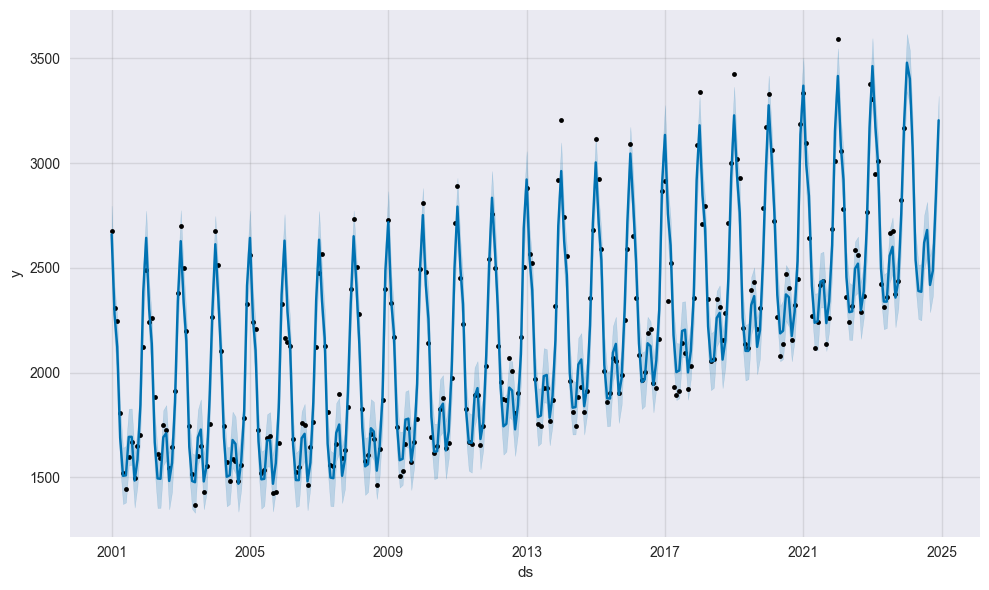

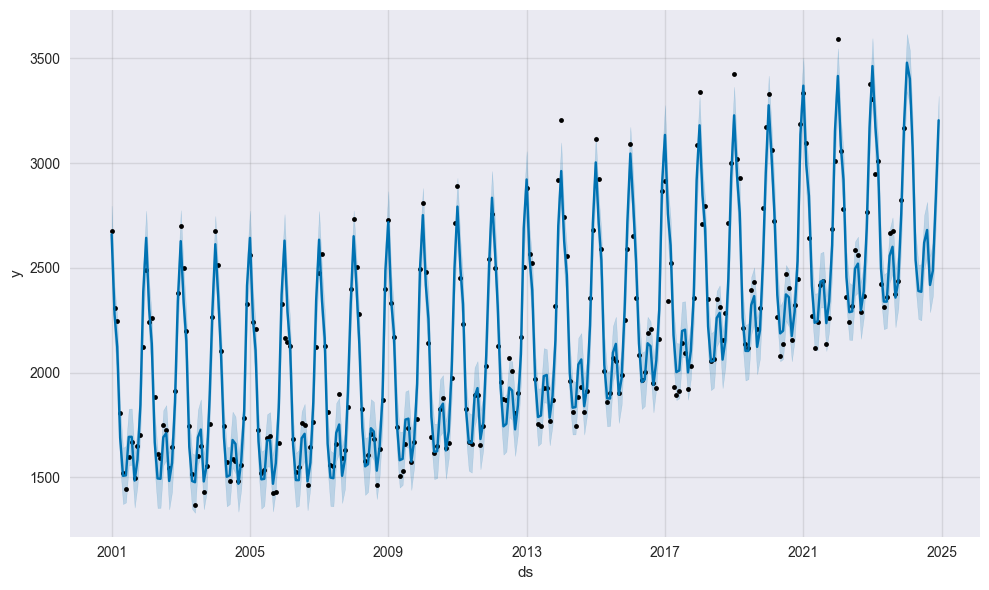

In [27]:
model.plot(forecast)

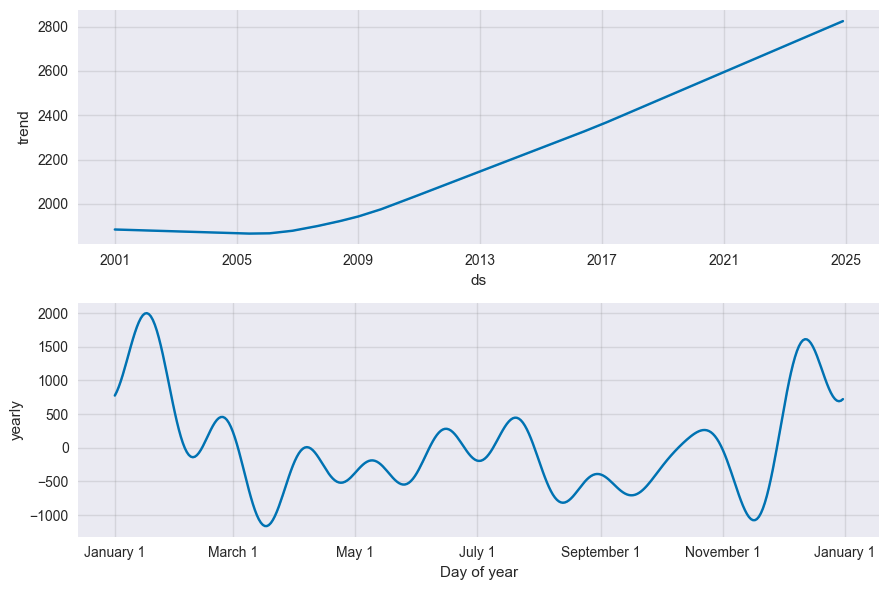

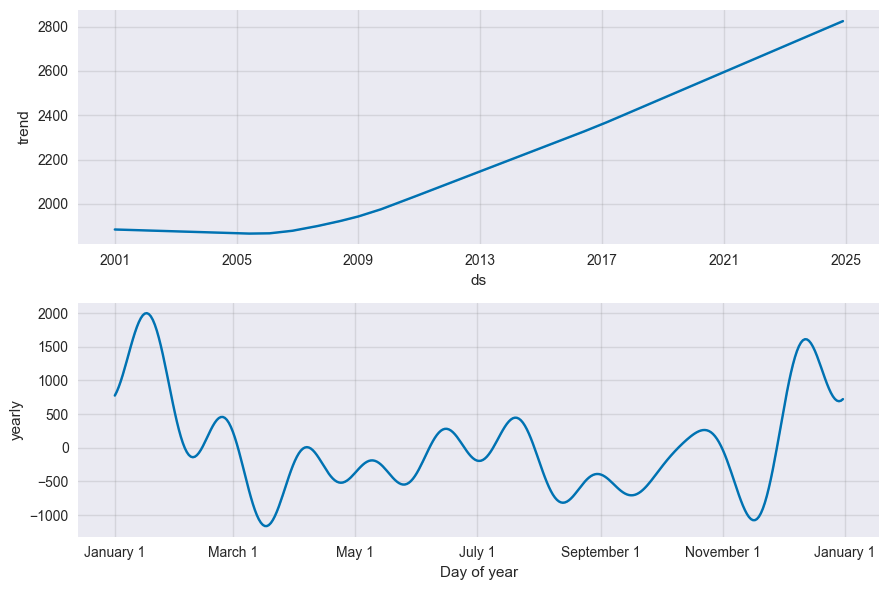

In [28]:
model.plot_components(forecast)

In [30]:
df_cv = cross_validation(model, horizon='365 days')
performance_metrics(df_cv)

  0%|          | 0/38 [00:00<?, ?it/s]

21:33:15 - cmdstanpy - INFO - Chain [1] start processing
21:33:16 - cmdstanpy - INFO - Chain [1] done processing
21:33:16 - cmdstanpy - INFO - Chain [1] start processing
21:33:16 - cmdstanpy - INFO - Chain [1] done processing
21:33:16 - cmdstanpy - INFO - Chain [1] start processing
21:33:16 - cmdstanpy - INFO - Chain [1] done processing
21:33:17 - cmdstanpy - INFO - Chain [1] start processing
21:33:17 - cmdstanpy - INFO - Chain [1] done processing
21:33:17 - cmdstanpy - INFO - Chain [1] start processing
21:33:17 - cmdstanpy - INFO - Chain [1] done processing
21:33:18 - cmdstanpy - INFO - Chain [1] start processing
21:33:18 - cmdstanpy - INFO - Chain [1] done processing
21:33:18 - cmdstanpy - INFO - Chain [1] start processing
21:33:18 - cmdstanpy - INFO - Chain [1] done processing
21:33:18 - cmdstanpy - INFO - Chain [1] start processing
21:33:19 - cmdstanpy - INFO - Chain [1] done processing
21:33:19 - cmdstanpy - INFO - Chain [1] start processing
21:33:19 - cmdstanpy - INFO - Chain [1]

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,57 days 12:00:00,18670.887810,136.641457,108.188687,0.045724,0.040264,0.046201,0.550000
1,58 days 00:00:00,19650.463093,140.180109,110.786775,0.045367,0.040264,0.045721,0.555556
2,58 days 12:00:00,19868.894126,140.957065,114.255964,0.047095,0.041655,0.047494,0.522222
3,59 days 00:00:00,17200.616766,131.151122,109.352209,0.044552,0.040544,0.045139,0.544444
4,59 days 12:00:00,15923.956391,126.190160,104.900983,0.042324,0.038974,0.042888,0.594444
...,...,...,...,...,...,...,...,...
104,363 days 00:00:00,22718.242069,150.725718,122.306698,0.055597,0.051237,0.056731,0.483333
105,363 days 12:00:00,22421.699287,149.738770,119.936775,0.054214,0.047035,0.055370,0.516667
106,364 days 00:00:00,24738.454794,157.284630,126.208062,0.054891,0.047035,0.056182,0.483333
107,364 days 12:00:00,23093.738309,151.966241,118.810869,0.051637,0.039205,0.052791,0.544444
